# 🤖 Future of Jobs & AI Impact Analysis

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,6)


In [2]:

df = pd.read_csv('Future of Jobs AI Dataset.csv')
df.head()


,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


## Dataset Overview

In [3]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           12343 non-null  object 
 1   country             12343 non-null  object 
 2   experience_level    12343 non-null  object 
 3   education_level     12343 non-null  object 
 4   year                12343 non-null  int64  
 5   salary              12343 non-null  float64
 6   ai_risk_score       12343 non-null  float64
 7   primary_skill       12343 non-null  object 
 8   skill_demand_score  12343 non-null  int64  
 9   job_openings        12343 non-null  int64  
 10  job_survival_class  12343 non-null  int64  
 11  salary_bucket       12343 non-null  object 
 12  ai_risk_category    12343 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 1.2+ MB


,year,salary,ai_risk_score,skill_demand_score,job_openings,job_survival_class
count,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000
mean,2025.054525,34553.729166,0.396008,79.453374,25223.652029,1.310054
std,6.058714,18024.702961,0.187665,11.483535,14163.309081,0.658417
min,2015.000000,3875.170000,0.050000,60.000000,1002.000000,0.000000
25%,2020.000000,21331.405000,0.260000,70.000000,12993.000000,1.000000
50%,2025.000000,31573.380000,0.360000,79.000000,24896.000000,1.000000
75%,2030.000000,45307.845000,0.490000,89.000000,37440.500000,2.000000
max,2035.000000,113589.260000,0.850000,99.000000,49998.000000,2.000000


## Salary Trends Over Time

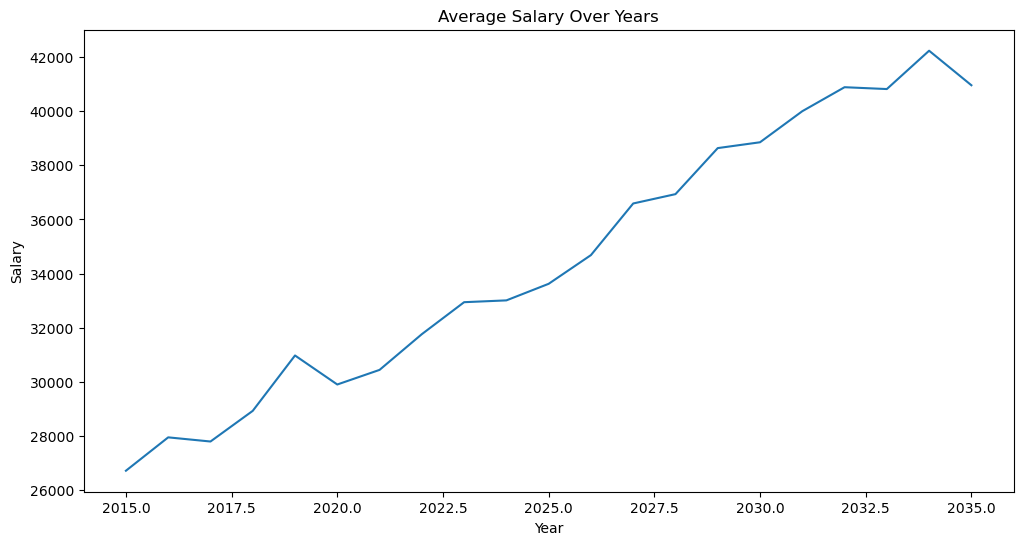

In [4]:

salary_trend = df.groupby('year')['salary'].mean()

plt.figure()
plt.plot(salary_trend)
plt.title("Average Salary Over Years")
plt.xlabel("Year")
plt.ylabel("Salary")
plt.show()


## AI Risk Distribution

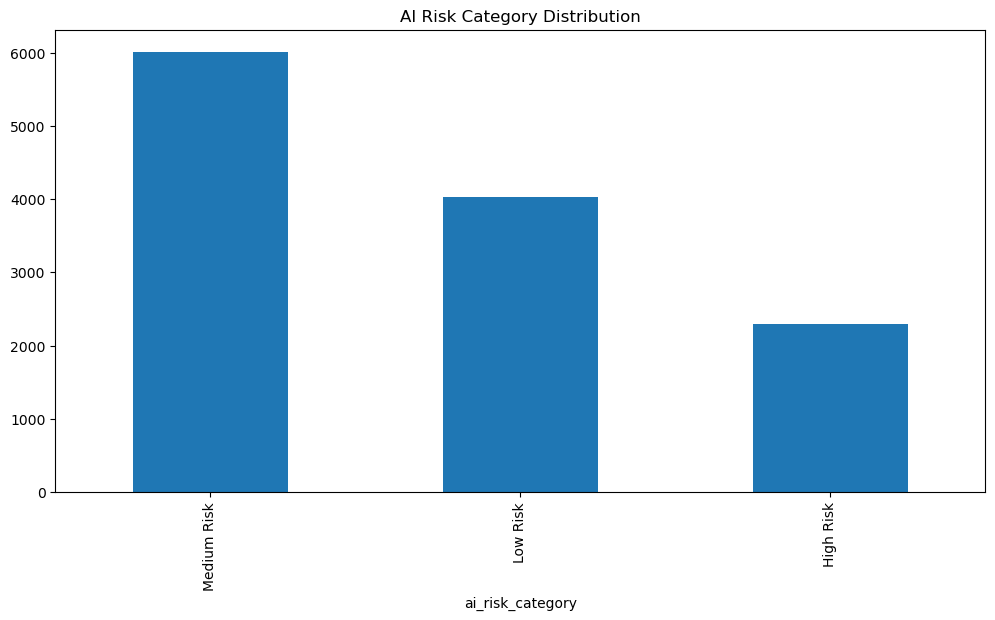

In [5]:

df['ai_risk_category'].value_counts().plot(kind='bar')
plt.title("AI Risk Category Distribution")
plt.show()


## Salary by Experience Level

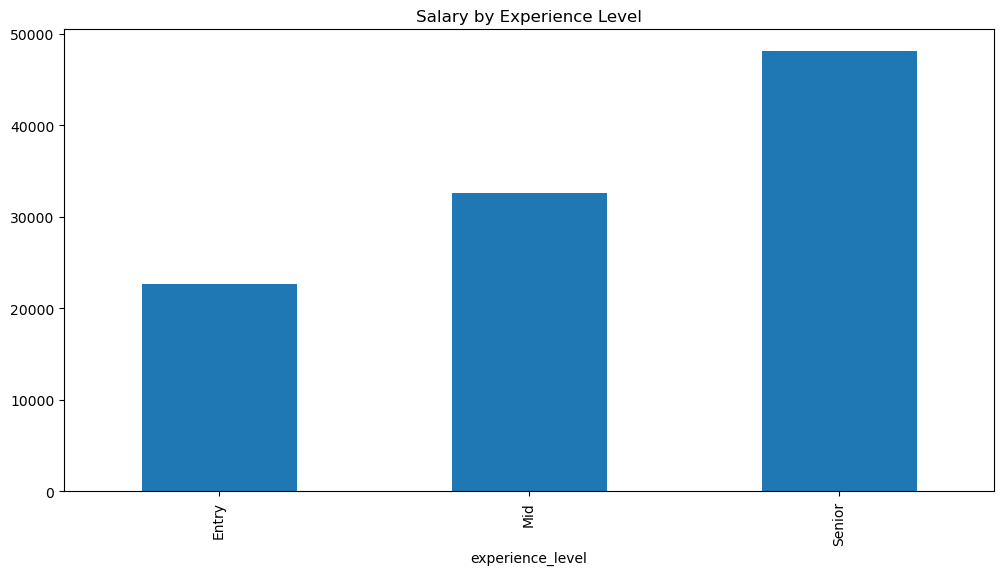

In [6]:

df.groupby('experience_level')['salary'].mean().plot(kind='bar')
plt.title("Salary by Experience Level")
plt.show()


## Job Openings vs Skill Demand

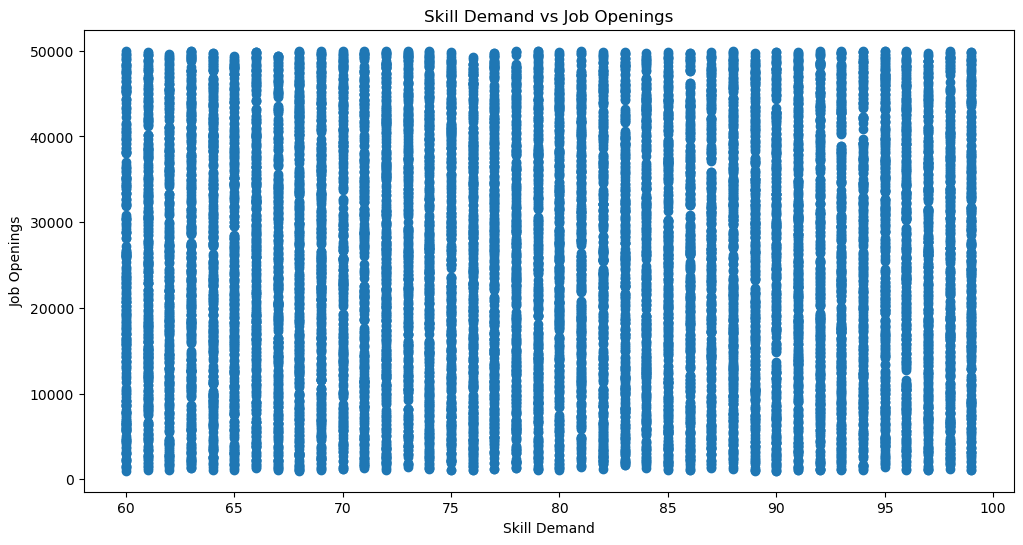

In [7]:

plt.figure()
plt.scatter(df['skill_demand_score'], df['job_openings'])
plt.xlabel("Skill Demand")
plt.ylabel("Job Openings")
plt.title("Skill Demand vs Job Openings")
plt.show()


## AI Risk vs Salary

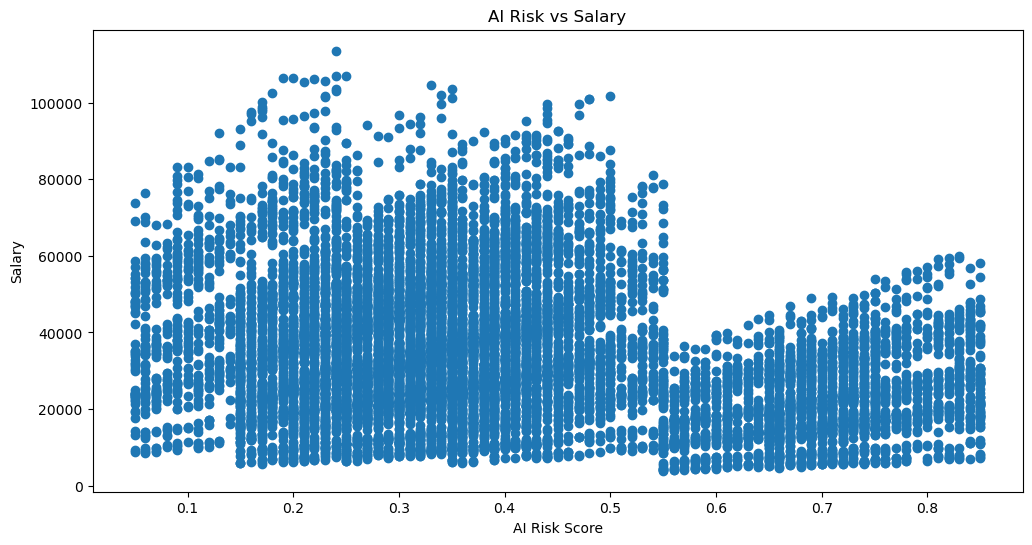

In [8]:

plt.figure()
plt.scatter(df['ai_risk_score'], df['salary'])
plt.xlabel("AI Risk Score")
plt.ylabel("Salary")
plt.title("AI Risk vs Salary")
plt.show()


## Top Skills by Demand

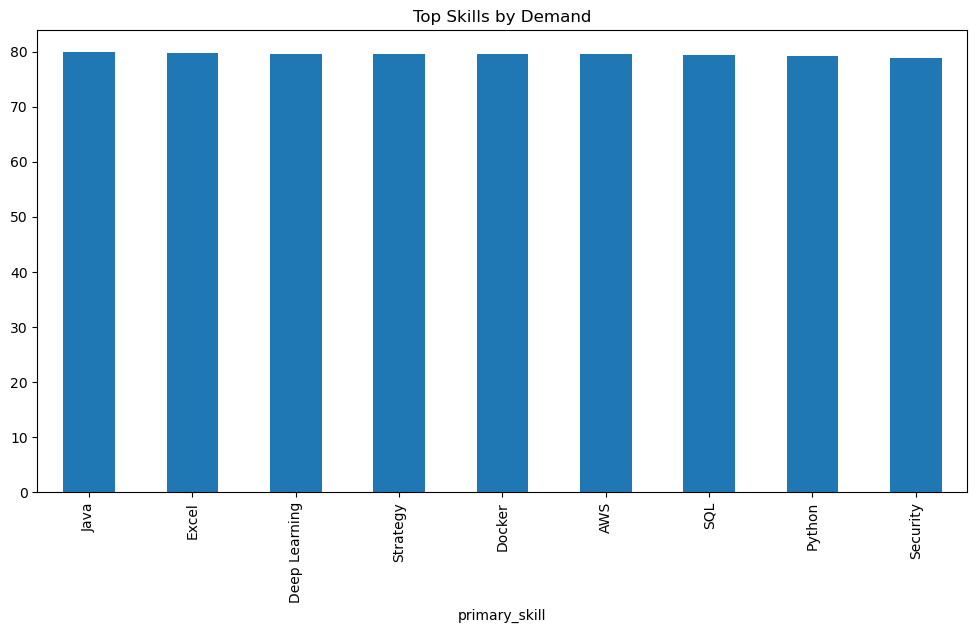

In [9]:

df.groupby('primary_skill')['skill_demand_score'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Skills by Demand")
plt.show()


## Country-wise Salary

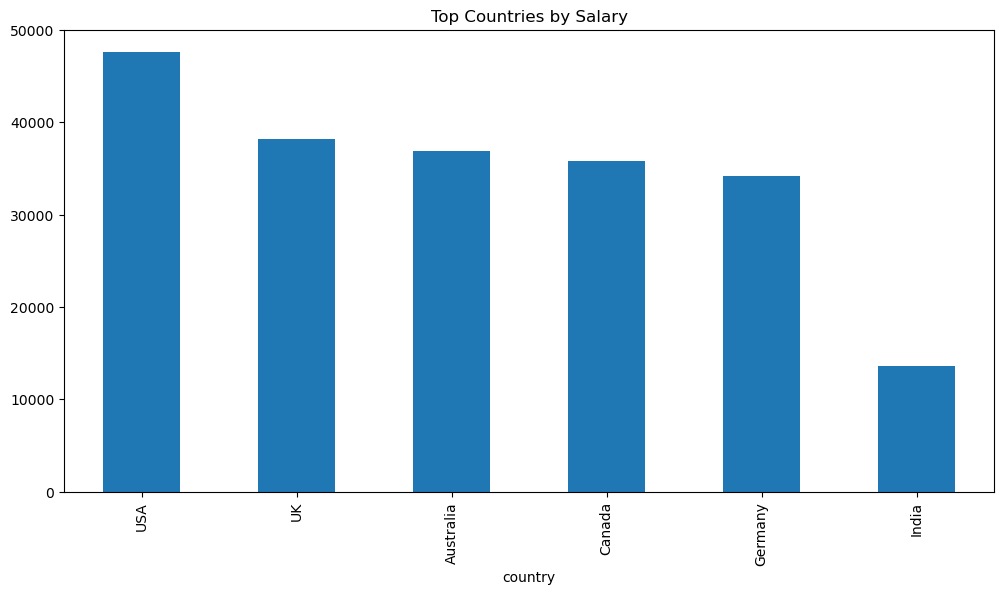

In [10]:

df.groupby('country')['salary'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Countries by Salary")
plt.show()


## Correlation Analysis

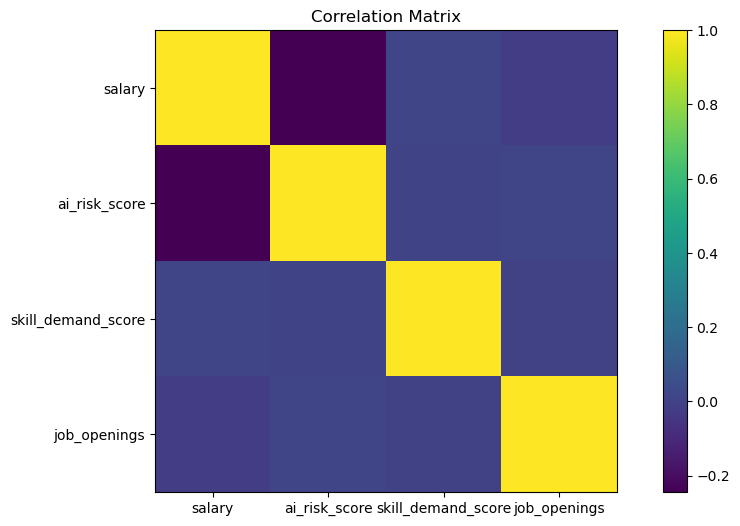

In [11]:

corr = df[['salary','ai_risk_score','skill_demand_score','job_openings']].corr()

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()


High Risk Jobs

C:\Users\thear\AppData\Local\Temp\ipykernel_8464\2895933297.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_risk['job_openings'][i],
C:\Users\thear\AppData\Local\Temp\ipykernel_8464\2895933297.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_risk['ai_risk_score'][i],


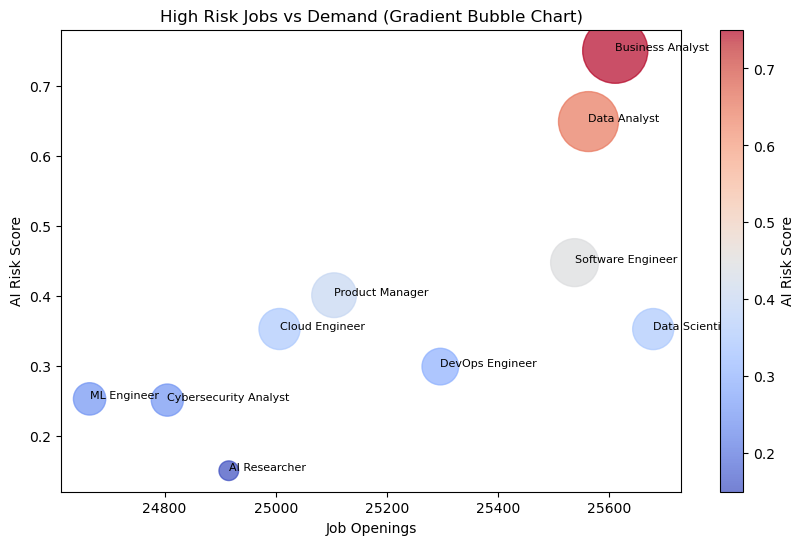

In [12]:
top_risk = df.groupby('job_title').agg({
    'ai_risk_score': 'mean',
    'job_openings': 'mean'
}).sort_values(by='ai_risk_score', ascending=False).head(15)

plt.figure(figsize=(10,6))


sizes = (top_risk['ai_risk_score'] - top_risk['ai_risk_score'].min()) / \
        (top_risk['ai_risk_score'].max() - top_risk['ai_risk_score'].min())

sizes = sizes * 2000 + 200  

scatter = plt.scatter(
    top_risk['job_openings'],
    top_risk['ai_risk_score'],
    s=sizes,
    c=top_risk['ai_risk_score'],
    cmap='coolwarm',               
    alpha=0.7
)

plt.colorbar(scatter, label='AI Risk Score')

plt.xlabel("Job Openings")
plt.ylabel("AI Risk Score")
plt.title("High Risk Jobs vs Demand (Gradient Bubble Chart)")

for i, txt in enumerate(top_risk.index):
    plt.text(
        top_risk['job_openings'][i],
        top_risk['ai_risk_score'][i],
        txt,
        fontsize=8
    )

plt.show()

Top Countries at Risk

In [13]:
country_risk = df.groupby('country')['ai_risk_score'].mean() \
                 .sort_values(ascending=False)

print(country_risk.head(10))

country
India        0.401156
USA          0.399007
Australia    0.396486
Germany      0.393889
Canada       0.393251
UK           0.392503
Name: ai_risk_score, dtype: float64


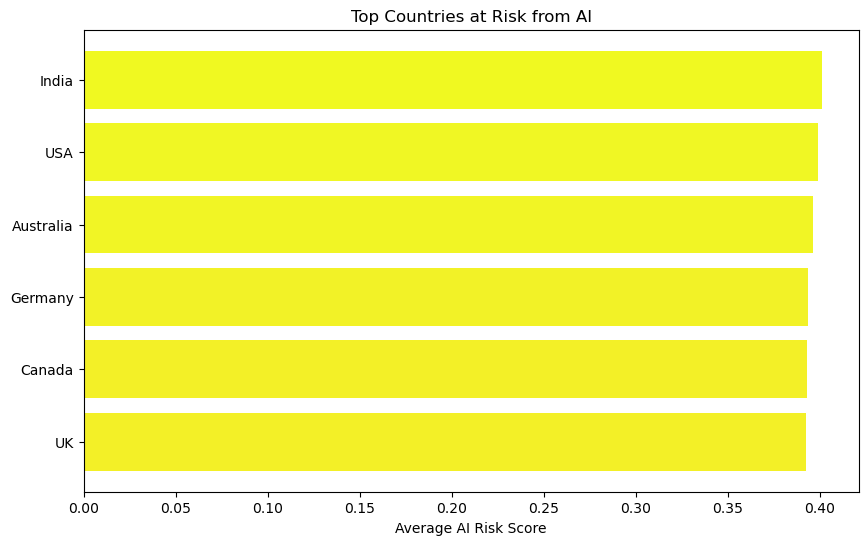

In [14]:
top_countries = country_risk.head(10)

plt.figure(figsize=(10,6))

colors = plt.cm.plasma(top_countries.values / top_countries.max())

plt.barh(top_countries.index, top_countries.values, color=colors)

plt.xlabel("Average AI Risk Score")
plt.title("Top Countries at Risk from AI")

plt.gca().invert_yaxis()

plt.show()

Salary Trend for High Risk Job

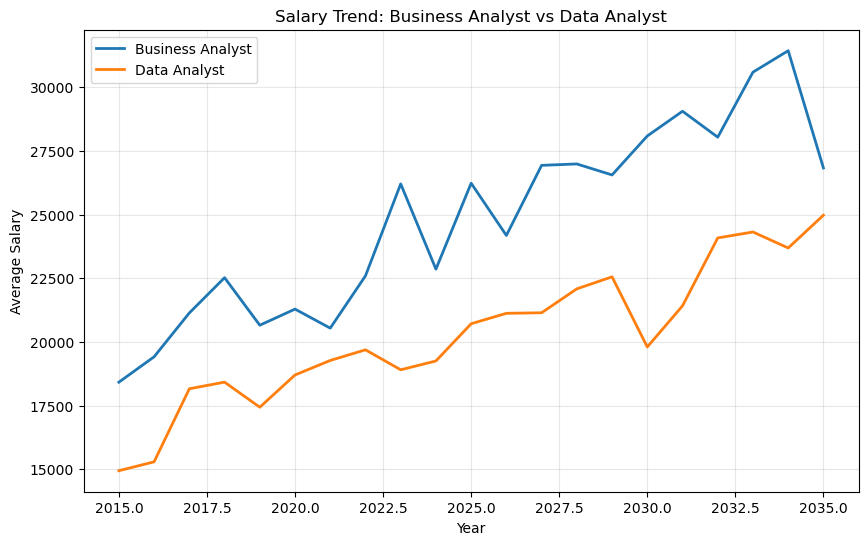

In [15]:

jobs = ['Business Analyst', 'Data Analyst']
df_filtered = df[df['job_title'].isin(jobs)]


salary_trend = df_filtered.groupby(['year', 'job_title'])['salary'].mean().reset_index()

pivot_df = salary_trend.pivot(index='year', columns='job_title', values='salary')

plt.figure(figsize=(10,6))

plt.plot(pivot_df.index, pivot_df['Business Analyst'], label='Business Analyst', linewidth=2)
plt.plot(pivot_df.index, pivot_df['Data Analyst'], label='Data Analyst', linewidth=2)

plt.title("Salary Trend: Business Analyst vs Data Analyst")
plt.xlabel("Year")
plt.ylabel("Average Salary")

plt.legend()
plt.grid(alpha=0.3)

plt.show()